In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [33]:
tr = pd.read_csv('train.csv', parse_dates=['Month'], index_col='Month')
te = pd.read_csv('test.csv', parse_dates=['Month'], index_col='Month')
d, D, m = 0, 1, 132

In [34]:
tr = tr.iloc[-600:].copy()

In [35]:
df_sf = tr.reset_index().rename(columns={'Month': 'ds', 'value': 'y'})
df_sf['unique_id'] = 'sun'

In [36]:
mdl = AutoARIMA(season_length=m, d=d, D=D, approximation=True)
sf = StatsForecast(models=[mdl], freq='MS', n_jobs=-1, verbose=True)

In [37]:
h, step, n_w = 12, 12, 5
cv = sf.cross_validation(df=df_sf, h=h, step_size=step, n_windows=n_w)

Cross Validation Time Series 1:   0%|          | 0/5 [00:00<?, ?it/s]

In [38]:
cv.head()

,unique_id,ds,cutoff,y,AutoARIMA
0,sun,1932-01-01,1931-12-01,12.1,33.996603
1,sun,1932-02-01,1931-12-01,10.6,32.933726
2,sun,1932-03-01,1931-12-01,11.2,29.145106
3,sun,1932-04-01,1931-12-01,11.2,30.030144
4,sun,1932-05-01,1931-12-01,17.9,26.009775


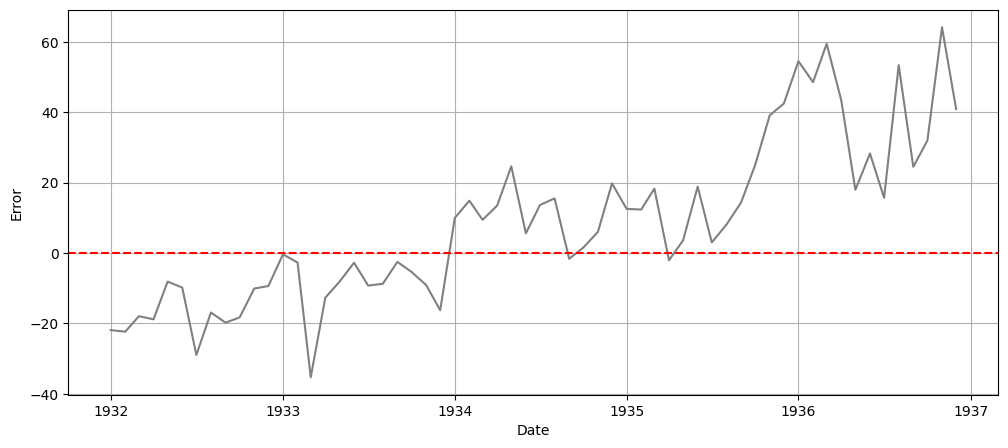

In [39]:
cv['err'] = cv['y'] - cv['AutoARIMA']

plt.figure(figsize=(12, 5))
plt.plot(cv['ds'], cv['err'], color='gray')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Date")
plt.ylabel("Error")
plt.grid(True)
plt.show()

In [40]:
cv['err'].mean()

8.254912283653082

In [41]:
b_p, b_d, b_q = 2, 0, 2
b_P, b_D, b_Q = 1, 1, 1

res = SARIMAX(
    tr['value'],
    order=(b_p, b_d, b_q),
    seasonal_order=(b_P, b_D, b_Q, m),
    enforce_invertibility=False
).fit(
    method='lbfgs',
    disp=False
)

In [42]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                       
=============================================================================================
Dep. Variable:                                 value   No. Observations:                  600
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 132)   Log Likelihood               -9956.695
Date:                               Sat, 11 Apr 2026   AIC                          19927.390
Time:                                       00:14:18   BIC                          19956.430
Sample:                                   01-01-1887   HQIC                         19938.817
                                        - 12-01-1936                                         
Covariance Type:                                 opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7026   2.03e-24   3.46e+23      0.000       0.703       0.703
ar.L2          0.1884   1.88e-24      1e+23      0.000       0.188       0.188
ma.L1         -0.1488    5.3e-25  -2.81e+23      0.000      -0.149      -0.149
ma.L2         -0.2362   3.26e-25  -7.25e+23      0.000      -0.236      -0.236
ar.S.L132      0.0600   1.27e-23   4.74e+21      0.000       0.060       0.060
ma.S.L132  -1.656e+14   1.02e-33  -1.62e+47      0.000   -1.66e+14   -1.66e+14
sigma2       1.75e-11   8.84e-11      0.198      0.843   -1.56e-10    1.91e-10
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):                67.48
Prob(Q):                              0.71   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                             0.10
Prob(H) (two-sided):                  0.73   Kurtosis:                         4.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.93e+61. Standard errors may be unstable.
"""

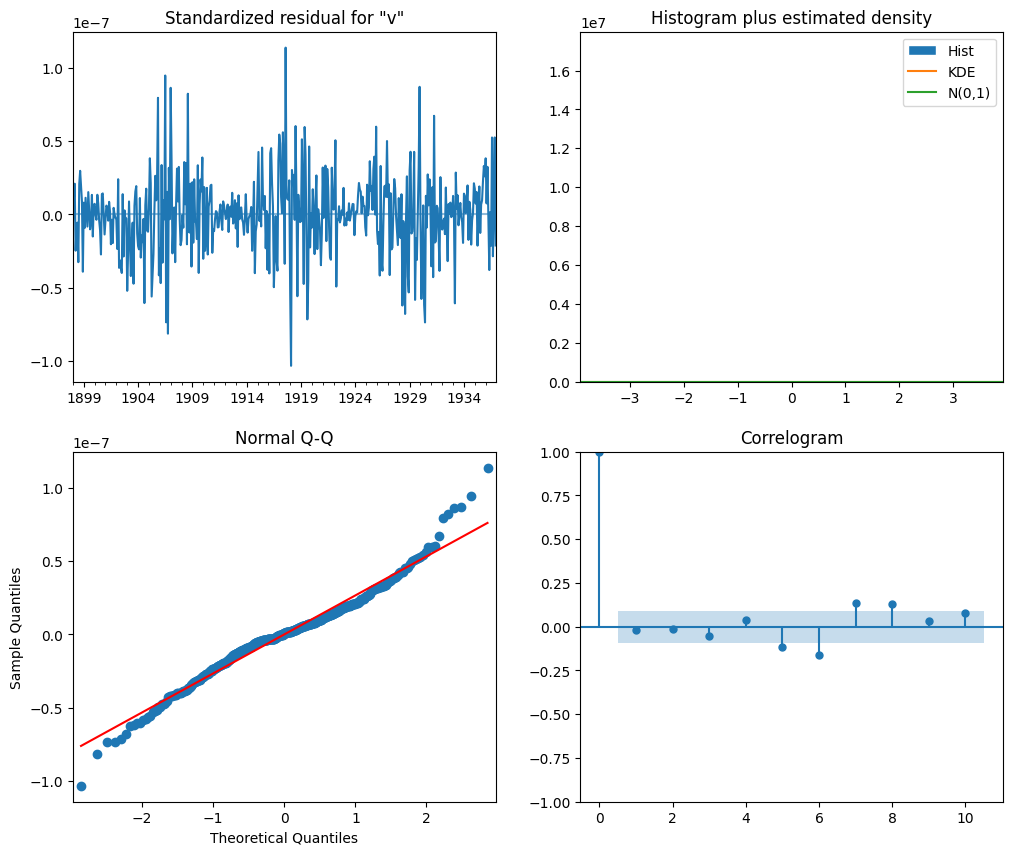

In [43]:
fig_diag = res.plot_diagnostics(figsize=(12, 10))

In [44]:
preds = res.get_forecast(steps=len(te)).predicted_mean
preds.index = te.index
y_true = te['value']
mae = mean_absolute_error(y_true, preds)
mse = mean_squared_error(y_true, preds)
mape = np.mean(np.abs((y_true - preds) / y_true)) * 100
smape = np.mean(2 * np.abs(preds - y_true) / (np.abs(preds) + np.abs(y_true))) * 100
pd.DataFrame({'MAE': [mae], 'MSE': [mse], 'MAPE': [mape], 'SMAPE': [smape]})

,MAE,MSE,MAPE,SMAPE
0,40.316104,3225.237057,104.506571,69.968377


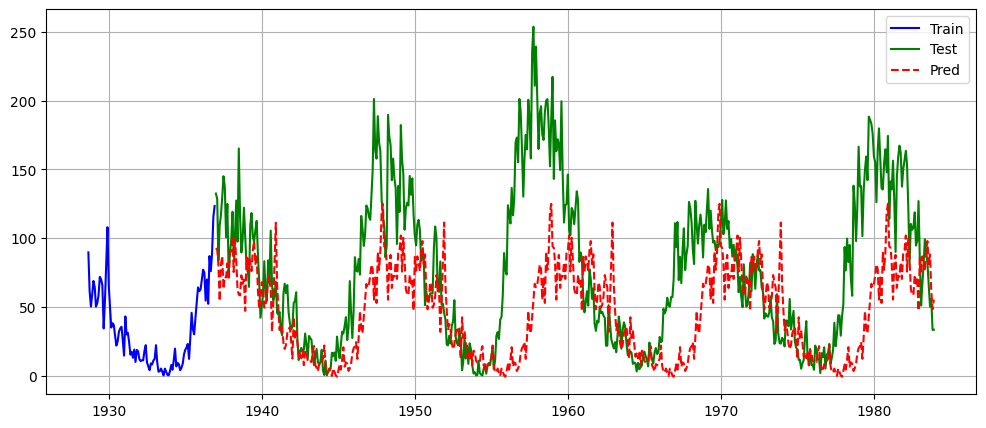

In [45]:
fig_tp = plt.figure(figsize=(12, 5))
plt.plot(tr.index[-100:], tr['value'].iloc[-100:], label='Train', color='blue')
plt.plot(te.index, y_true, label='Test', color='green')
plt.plot(preds.index, preds, label='Pred', color='red', linestyle='--')
plt.legend()
plt.grid(True)

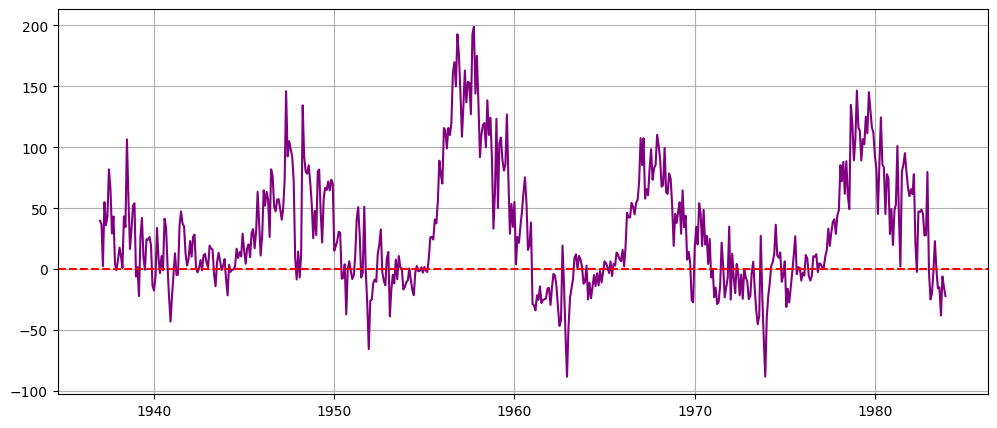

In [46]:
errs = y_true - preds
fig_e = plt.figure(figsize=(12, 5))
plt.plot(errs.index, errs, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.grid(True)